In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel("../data/Online Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [11]:
df.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

In [12]:
df.shape

(397924, 9)

In [13]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912476,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


In [14]:
top_countries = df['Country'].value_counts().head(10)

top_countries

Country
United Kingdom    354345
Germany             9042
France              8342
EIRE                7238
Spain               2485
Netherlands         2363
Belgium             2031
Switzerland         1842
Portugal            1462
Australia           1185
Name: count, dtype: int64

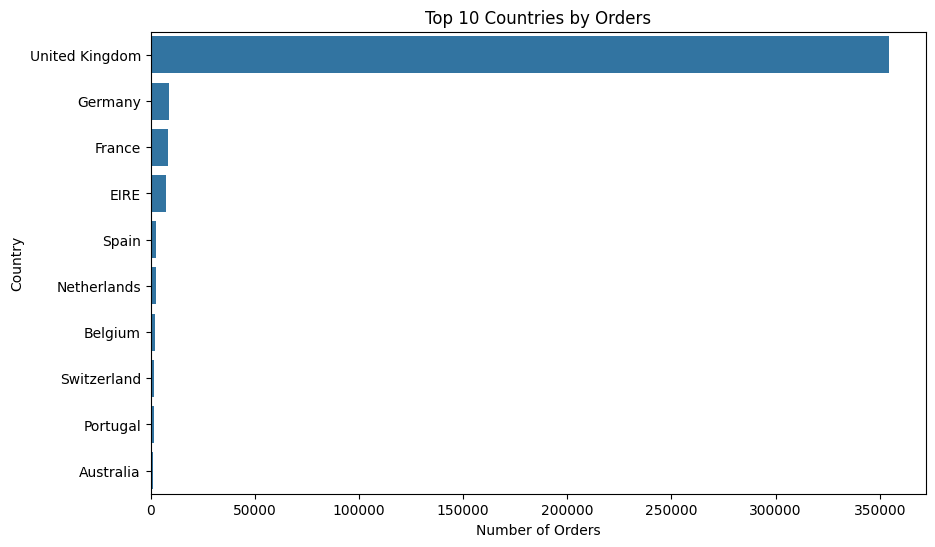

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Country")

plt.show()

In [16]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [17]:
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

monthly_revenue

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: TotalPrice, dtype: float64

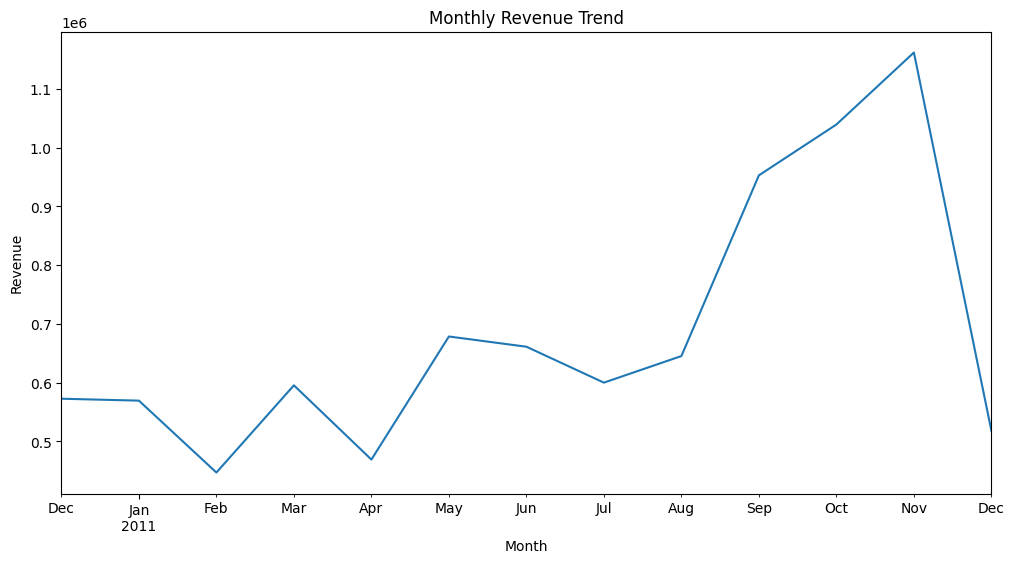

In [18]:
plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [19]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [20]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [21]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [22]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


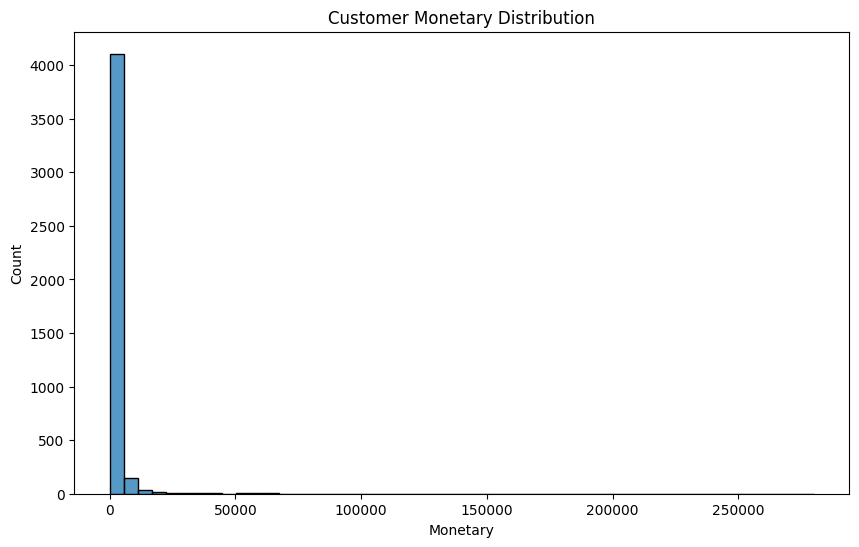

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(rfm['Monetary'], bins=50)

plt.title("Customer Monetary Distribution")

plt.show()

In [25]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [26]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [27]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [28]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [29]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [31]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [32]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [33]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

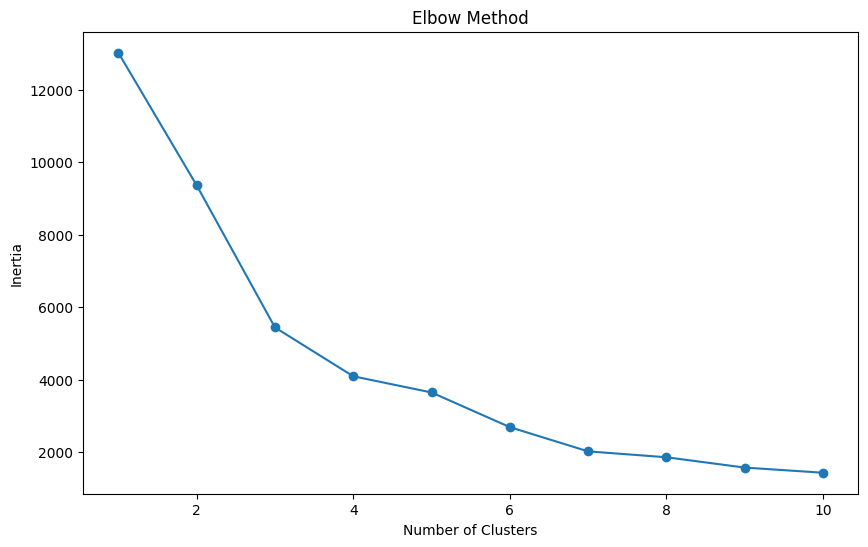

In [34]:
plt.figure(figsize=(10,6))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [36]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,0
12347.0,2,7,4310.00,4,4,4,444,3
12348.0,75,4,1797.24,2,3,4,234,3
12349.0,19,1,1757.55,3,1,4,314,3
12350.0,310,1,334.40,1,1,2,112,1


In [37]:
rfm['Cluster'].value_counts()

Cluster
3    3053
1    1062
0     211
2      13
Name: count, dtype: int64

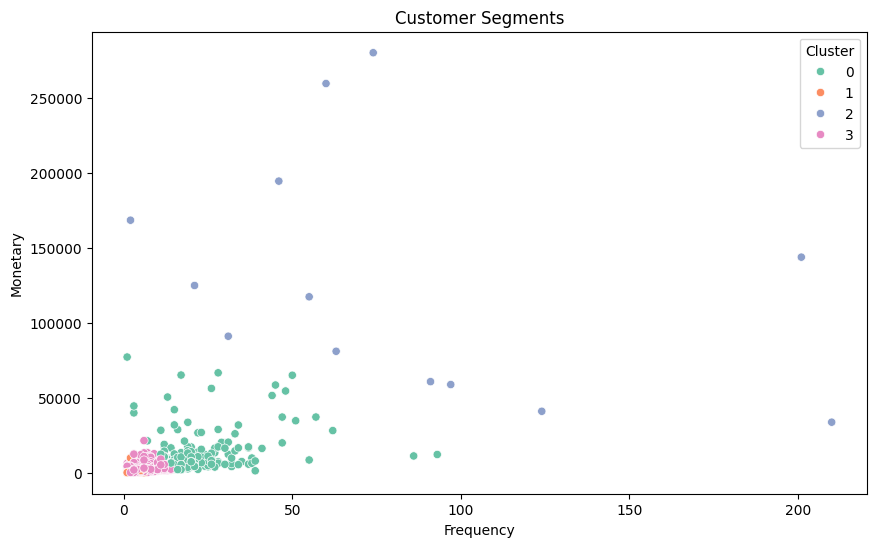

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

In [39]:
cluster_summary = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,15.672986,22.047393,12453.225924
1,248.564030,1.551789,478.107581
2,7.384615,82.692308,127338.313846
3,43.910580,3.655748,1349.698298


In [40]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [41]:
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

In [42]:
df[['CustomerID', 'InvoiceMonth', 'CohortMonth']].head()

,CustomerID,InvoiceMonth,CohortMonth
0,17850.0,2010-12,2010-12
1,17850.0,2010-12,2010-12
2,17850.0,2010-12,2010-12
3,17850.0,2010-12,2010-12
4,17850.0,2010-12,2010-12


In [43]:
invoice_year = df['InvoiceMonth'].dt.year
invoice_month = df['InvoiceMonth'].dt.month

cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

df['CohortIndex'] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

In [44]:
cohort_data = df.groupby(
    ['CohortMonth', 'CohortIndex']
)['CustomerID'].nunique().reset_index()

In [45]:
cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

In [46]:
cohort_sizes = cohort_counts.iloc[:,0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

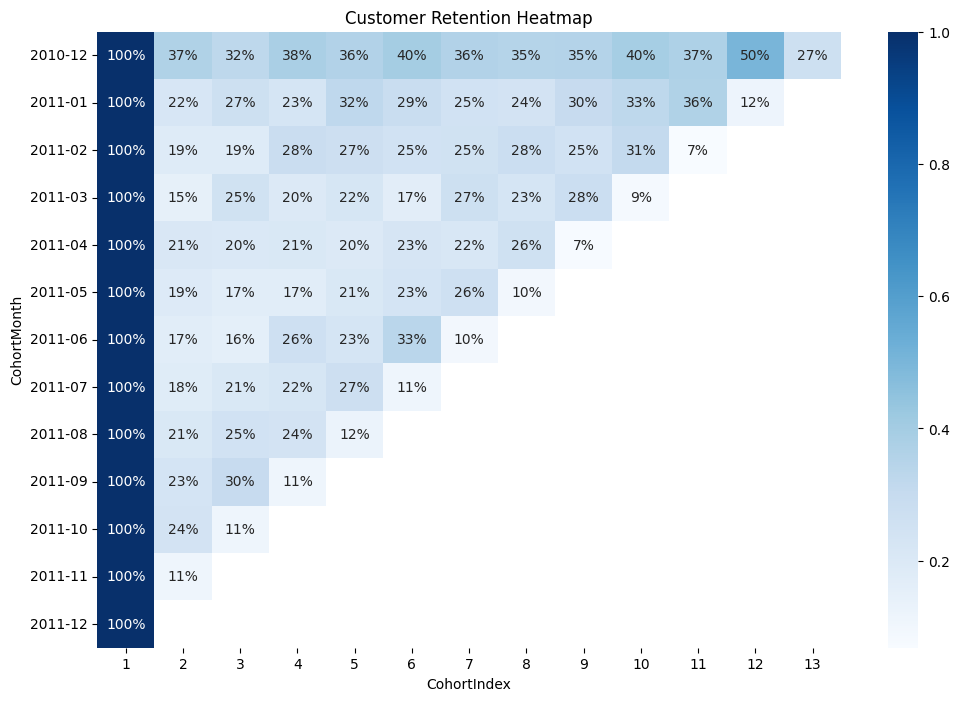

In [47]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.0%',
    cmap='Blues'
)

plt.title("Customer Retention Heatmap")

plt.show()

In [48]:
rfm['ChurnRisk'] = np.where(
    rfm['Recency'] > 90,
    'High Risk',
    'Low Risk'
)

In [49]:
rfm['ChurnRisk'].value_counts()

ChurnRisk
Low Risk     2890
High Risk    1449
Name: count, dtype: int64

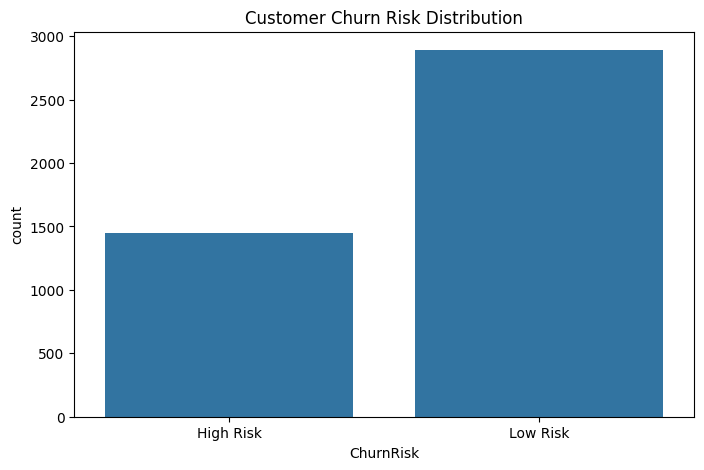

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='ChurnRisk',
    data=rfm
)

plt.title("Customer Churn Risk Distribution")

plt.show()

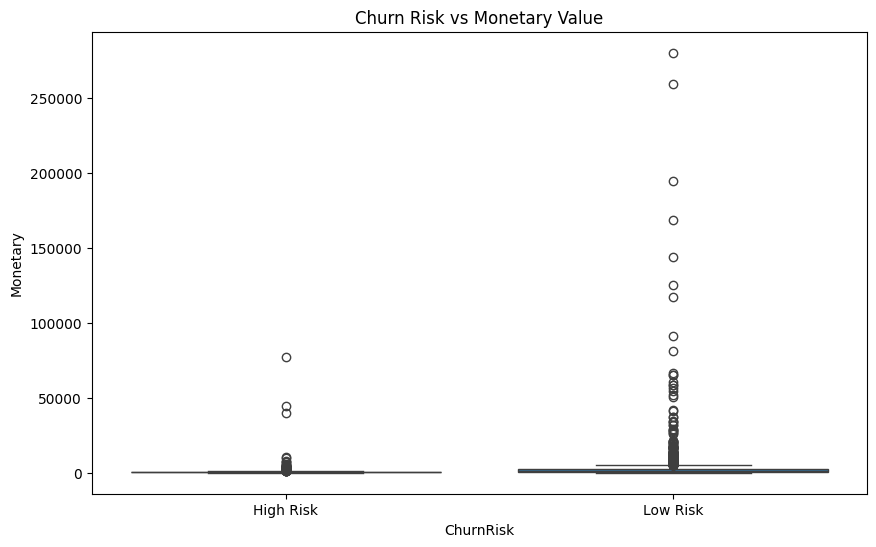

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='ChurnRisk',
    y='Monetary',
    data=rfm
)

plt.title("Churn Risk vs Monetary Value")

plt.show()

In [52]:
high_risk_customers = rfm[
    rfm['ChurnRisk'] == 'High Risk'
]

high_risk_customers.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,ChurnRisk
CustomerID,,,,,,,,,
12346.0,326,1,77183.6,1,1,4,114,0,High Risk
12350.0,310,1,334.4,1,1,2,112,1,High Risk
12353.0,204,1,89.0,1,1,1,111,1,High Risk
12354.0,232,1,1079.4,1,1,3,113,1,High Risk
12355.0,214,1,459.4,1,1,2,112,1,High Risk


In [53]:
average_order_value = (
    df.groupby('CustomerID')['TotalPrice']
    .mean()
)

In [54]:
purchase_frequency = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
)

In [55]:
customer_lifespan = (
    df.groupby('CustomerID')['InvoiceDate']
    .agg(lambda x: (x.max() - x.min()).days)
)

In [56]:
clv = pd.DataFrame({
    'AverageOrderValue': average_order_value,
    'PurchaseFrequency': purchase_frequency,
    'CustomerLifespan': customer_lifespan
})

In [57]:
clv['CLV'] = (
    clv['AverageOrderValue']
    * clv['PurchaseFrequency']
    * (clv['CustomerLifespan'] / 30)
)

In [58]:
clv.head()

,AverageOrderValue,PurchaseFrequency,CustomerLifespan,CLV
CustomerID,,,,
12346.0,77183.600000,1,0,0.000000
12347.0,23.681319,7,365,2016.858974
12348.0,57.975484,4,282,2179.878194
12349.0,24.076027,1,0,0.000000
12350.0,19.670588,1,0,0.000000


In [59]:
rfm = rfm.merge(
    clv[['CLV']],
    left_index=True,
    right_index=True
)

In [60]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,ChurnRisk,CLV
CustomerID,,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,0,High Risk,0.000000
12347.0,2,7,4310.00,4,4,4,444,3,Low Risk,2016.858974
12348.0,75,4,1797.24,2,3,4,234,3,Low Risk,2179.878194
12349.0,19,1,1757.55,3,1,4,314,3,Low Risk,0.000000
12350.0,310,1,334.40,1,1,2,112,1,High Risk,0.000000


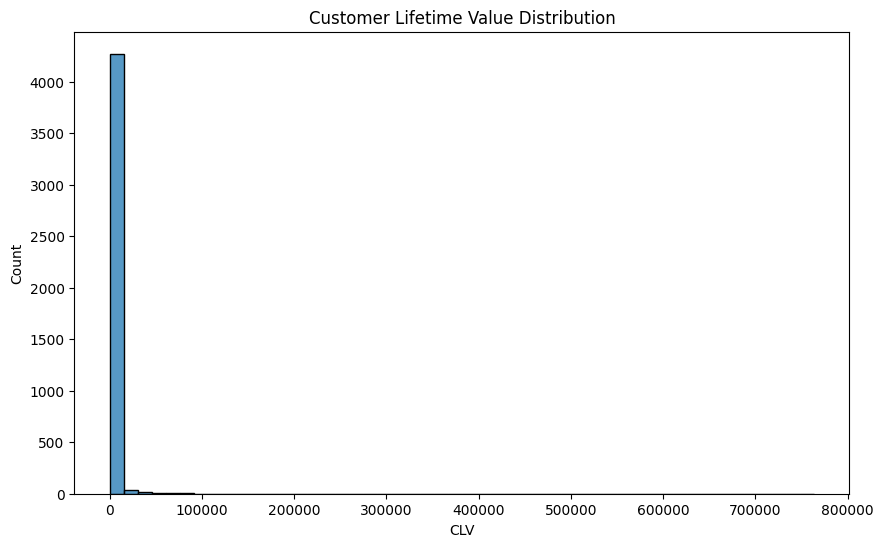

In [61]:
plt.figure(figsize=(10,6))

sns.histplot(
    rfm['CLV'],
    bins=50
)

plt.title("Customer Lifetime Value Distribution")

plt.show()

In [62]:
top_clv = rfm.sort_values(
    by='CLV',
    ascending=False
).head(10)

top_clv

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,ChurnRisk,CLV
CustomerID,,,,,,,,,,
16446.0,1,2,168472.50,4,2,4,424,2,Low Risk,763742.000000
17949.0,1,45,58510.48,4,4,4,444,0,Low Risk,463904.520000
18102.0,1,60,259657.30,4,4,4,444,2,Low Risk,440995.692807
17450.0,8,46,194550.79,4,4,4,444,2,Low Risk,317785.533735
16029.0,39,63,81024.84,3,4,4,344,2,Low Risk,235541.218760
16013.0,4,47,37130.60,4,4,4,444,0,Low Risk,153588.901535
17857.0,4,23,26879.04,4,4,4,444,0,Low Risk,137763.376000
15769.0,7,26,56252.72,4,4,4,444,0,Low Risk,136131.582400
16333.0,8,22,26626.80,4,4,4,444,0,Low Risk,131043.303111


# Customer Lifetime Value Insights
A small percentage of customers generate the majority of lifetime value.
High CLV customers often overlap with high-frequency segments.
Retention of top CLV customers is critical for revenue growth.

In [63]:
cluster_summary = rfm.groupby('Cluster')[[
    'Recency',
    'Frequency',
    'Monetary',
    'CLV'
]].mean()

cluster_summary

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,15.672986,22.047393,12453.225924,15413.085207
1,248.564030,1.551789,478.107581,73.424907
2,7.384615,82.692308,127338.313846,166360.405176
3,43.910580,3.655748,1349.698298,724.557295


In [64]:
persona_map = {
    0: 'VIP Customers',
    1: 'Loyal Customers',
    2: 'At Risk Customers',
    3: 'Budget Buyers'
}

In [65]:
rfm['Persona'] = rfm['Cluster'].map(persona_map)

In [66]:
rfm[['Cluster', 'Persona']].head()

,Cluster,Persona
CustomerID,,
12346.0,0,VIP Customers
12347.0,3,Budget Buyers
12348.0,3,Budget Buyers
12349.0,3,Budget Buyers
12350.0,1,Loyal Customers


In [67]:
rfm['Persona'].value_counts()

Persona
Budget Buyers        3053
Loyal Customers      1062
VIP Customers         211
At Risk Customers      13
Name: count, dtype: int64

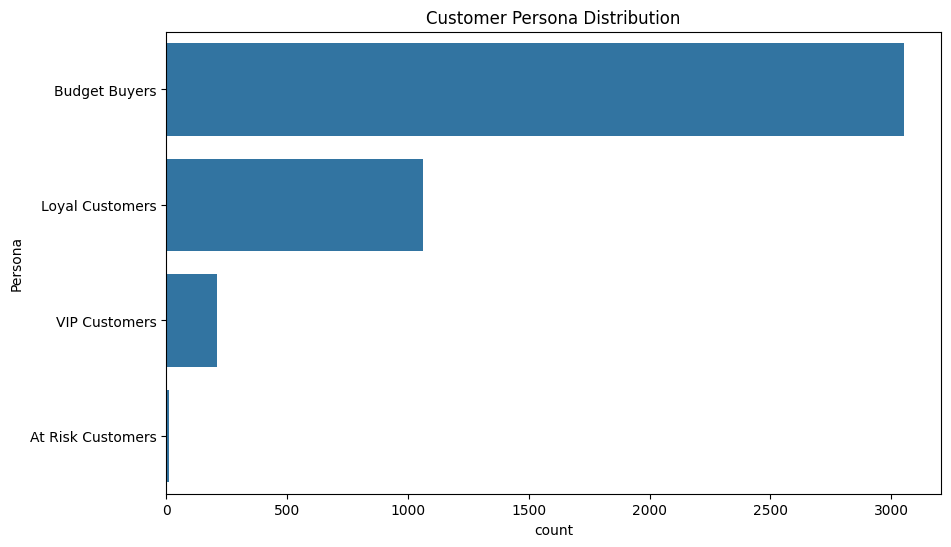

In [68]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Persona',
    data=rfm,
    order=rfm['Persona'].value_counts().index
)

plt.title("Customer Persona Distribution")

plt.show()

In [69]:
persona_revenue = rfm.groupby('Persona')['Monetary'].sum()

persona_revenue

Persona
At Risk Customers    1655398.080
Budget Buyers        4120628.903
Loyal Customers       507750.251
VIP Customers        2627630.670
Name: Monetary, dtype: float64

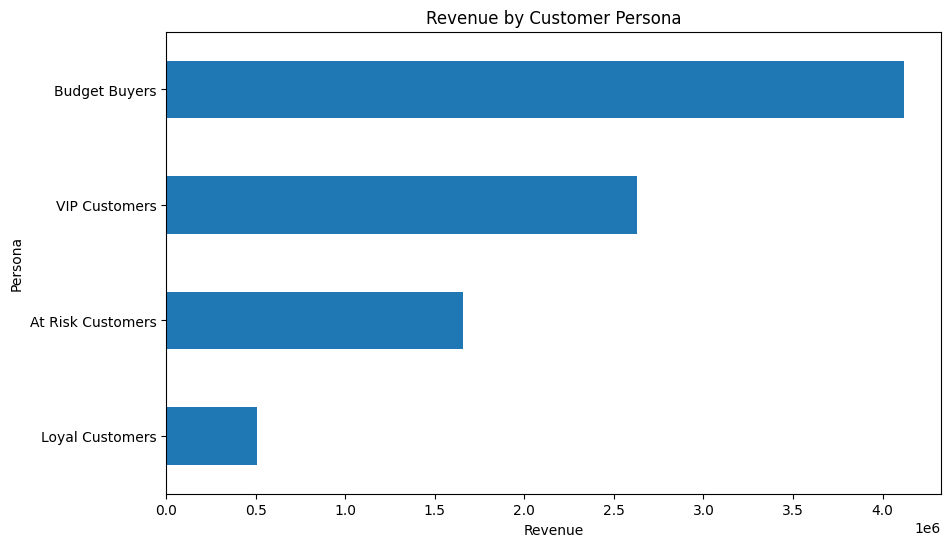

In [70]:
plt.figure(figsize=(10,6))

persona_revenue.sort_values().plot(kind='barh')

plt.title("Revenue by Customer Persona")

plt.xlabel("Revenue")

plt.show()

# Customer Persona Insights
VIP Customers generate the highest revenue despite smaller population.
At Risk Customers show declining engagement.
Loyal Customers form the stable revenue base.
Budget Buyers contribute low average order values.

In [71]:
total_customers = rfm.shape[0]

total_revenue = df['TotalPrice'].sum()

average_clv = rfm['CLV'].mean()

high_risk_customers = (
    rfm['ChurnRisk'] == 'High Risk'
).sum()

vip_customers = (
    rfm['Persona'] == 'VIP Customers'
).sum()

In [72]:
print("Total Customers:", total_customers)

print("Total Revenue:", round(total_revenue, 2))

print("Average CLV:", round(average_clv, 2))

print("High Risk Customers:", high_risk_customers)

print("VIP Customers:", vip_customers)

Total Customers: 4339
Total Revenue: 8911407.9
Average CLV: 1775.73
High Risk Customers: 1449
VIP Customers: 211


In [73]:
persona_summary = rfm.groupby('Persona').agg({
    'Monetary': 'sum',
    'CLV': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean'
})

persona_summary

,Monetary,CLV,Frequency,Recency
Persona,,,,
At Risk Customers,1655398.080,166360.405176,82.692308,7.384615
Budget Buyers,4120628.903,724.557295,3.655748,43.910580
Loyal Customers,507750.251,73.424907,1.551789,248.564030
VIP Customers,2627630.670,15413.085207,22.047393,15.672986


In [74]:
persona_summary['RevenuePercent'] = (
    persona_summary['Monetary']
    / persona_summary['Monetary'].sum()
) * 100

persona_summary

,Monetary,CLV,Frequency,Recency,RevenuePercent
Persona,,,,,
At Risk Customers,1655398.080,166360.405176,82.692308,7.384615,18.576168
Budget Buyers,4120628.903,724.557295,3.655748,43.910580,46.239931
Loyal Customers,507750.251,73.424907,1.551789,248.564030,5.697756
VIP Customers,2627630.670,15413.085207,22.047393,15.672986,29.486145


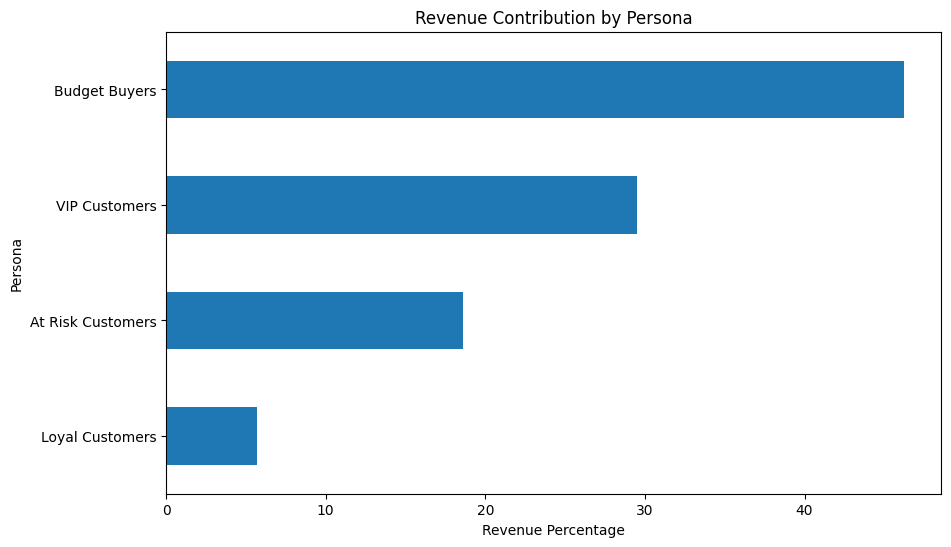

In [75]:
plt.figure(figsize=(10,6))

persona_summary['RevenuePercent'].sort_values().plot(
    kind='barh'
)

plt.title("Revenue Contribution by Persona")

plt.xlabel("Revenue Percentage")

plt.show()

# Executive Business Insights

## Revenue Insights
- VIP Customers contribute the largest share of revenue.
- Loyal Customers generate stable recurring purchases.
- Budget Buyers contribute low monetary value.

## Retention Insights
- High-risk customers show lower purchase frequency.
- Retention campaigns should target inactive users.

## Business Recommendations
- Focus retention efforts on high CLV customers.
- Introduce loyalty rewards for repeat customers.

In [76]:
rfm.to_csv(
    "../outputs/customer_segments.csv"
)

In [77]:
from prophet import Prophet

In [78]:
monthly_sales = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
)['TotalPrice'].sum()

In [79]:
forecast_df = monthly_sales.reset_index()

In [80]:
forecast_df['InvoiceDate'] = (
    forecast_df['InvoiceDate']
    .astype(str)
)

forecast_df['InvoiceDate'] = pd.to_datetime(
    forecast_df['InvoiceDate']
)

In [81]:
forecast_df.columns = ['ds', 'y']

In [82]:
forecast_df.head()

,ds,y
0,2010-12-01,572713.890
1,2011-01-01,569445.040
2,2011-02-01,447137.350
3,2011-03-01,595500.760
4,2011-04-01,469200.361


In [83]:
model = Prophet()

In [84]:
model.fit(forecast_df)

09:35:45 - cmdstanpy - INFO - Chain [1] start processing
09:35:45 - cmdstanpy - INFO - Chain [1] done processing


In [85]:
future = model.make_future_dataframe(
    periods=6,
    freq='ME'
)

In [86]:
forecast = model.predict(future)

In [87]:
forecast[['ds', 'yhat']].to_csv(
    r'C:\projects\customer-segmentation-retention\outputs\sales_forecast.csv',
    index=False
)

In [88]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
14,2012-01-31,9.679442e+05,756890.504514,1.187782e+06
15,2012-02-29,1.001596e+06,790898.975088,1.213448e+06
16,2012-03-31,1.037568e+06,824987.334610,1.270630e+06
17,2012-04-30,1.072379e+06,855120.127044,1.291469e+06
18,2012-05-31,1.108351e+06,880874.218760,1.319350e+06


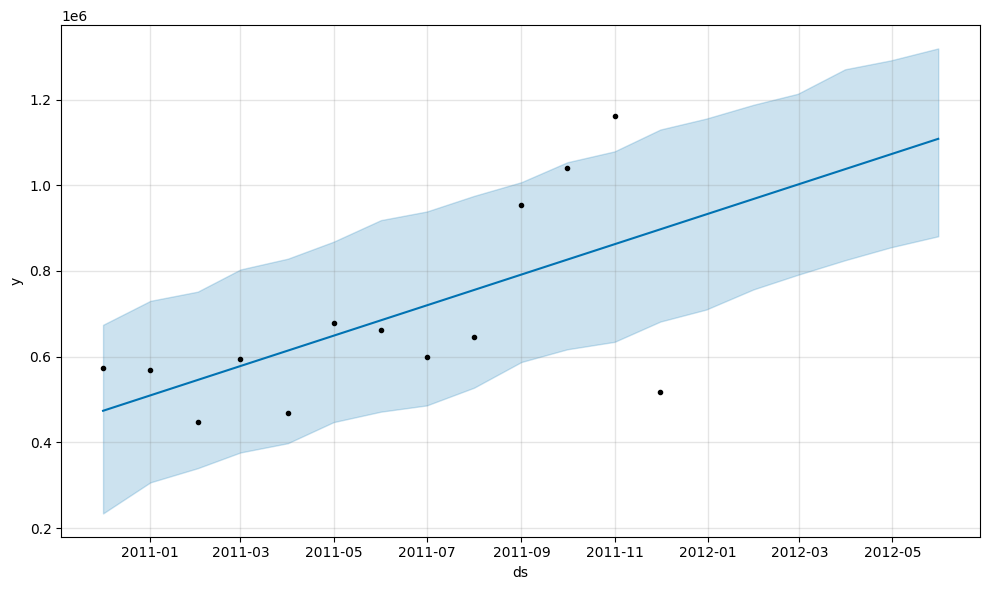

In [89]:
fig = model.plot(forecast)

In [90]:
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

In [91]:
customer_product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [92]:
customer_product_matrix = (
    customer_product_matrix > 0
).astype(int)

In [93]:
from sklearn.metrics.pairwise import cosine_similarity

In [94]:
product_similarity = cosine_similarity(
    customer_product_matrix.T
)

In [95]:
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product_matrix.columns,
    columns=customer_product_matrix.columns
)

In [96]:
def recommend_products(product_name, n=5):

    similar_products = product_similarity_df[
        product_name
    ].sort_values(ascending=False)

    return similar_products[1:n+1]

In [97]:
recommend_products(
    'WHITE HANGING HEART T-LIGHT HOLDER'
)

Description
RED HANGING HEART T-LIGHT HOLDER     0.543485
CANDLEHOLDER PINK HANGING HEART      0.472557
HEART OF WICKER LARGE                0.411281
HEART OF WICKER SMALL                0.379811
WOODEN PICTURE FRAME WHITE FINISH    0.362919
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [98]:
from mlxtend.frequent_patterns import apriori, association_rules

# Reduce dataset size
small_matrix = customer_product_matrix.iloc[:1000, :100]

# Convert to boolean
small_matrix = small_matrix.astype(bool)

# Generate itemsets
frequent_itemsets = apriori(
    small_matrix,
    min_support=0.05,
    use_colnames=True,
    low_memory=True
)

print("Frequent Itemsets Shape:")
print(frequent_itemsets.shape)

# Generate rules
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

print("Rules Shape:")
print(rules.shape)

# Save rules
rules.to_csv(
    "../outputs/association_rules.csv",
    index=False
)

print("association_rules.csv saved successfully!")

Frequent Itemsets Shape:
(5, 2)
Rules Shape:
(0, 14)
association_rules.csv saved successfully!
